# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

# 2. Load Dataset

In [4]:
df = pd.read_csv("AmesHousing.csv")

print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# 3. Initial Inspection

In [12]:
df.info()

df.isnull().sum().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Alley            198 non-null    object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Cond        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
BsmtFin Type 1      80
Bsmt Qual           80
Bsmt Cond           80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

# 4. Drop ID Columns

In [14]:
df.drop(['Order','PID'], axis=1, inplace=True)

KeyError: "['Order', 'PID'] not found in axis"

# 5. Separate Features and Target

In [ ]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

# 6. Create Classification Target

In [ ]:
median_price = y.median()

df["HighPrice"] = np.where(df["SalePrice"] > median_price, 1, 0)

df["HighPrice"].value_counts()

# 7. Identify Numeric & Categorical Columns

In [ ]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

# 8. Data Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 9. Train-Test Split for Regression

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 10. Regression Models
Linear Regression:

In [16]:
lr = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("R2:", r2_score(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
print("MAE:", mean_absolute_error(y_test,pred))

R2: 0.8906138563152585
RMSE: 29614.331833920856
MAE: 16007.107600862446


Ridge:

In [17]:
ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(alpha=1))
])

ridge.fit(X_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Lasso:

In [18]:
lasso = Pipeline([
    ("prep", preprocessor),
    ("model", Lasso(alpha=100))
])

lasso.fit(X_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Decision Tree Regressor:

In [19]:
tree_reg = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_reg.fit(X_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Random Forest Regressor:

In [20]:
rf_reg = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_reg.fit(X_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Gradient Boosting Regressor:

In [21]:
gb_reg = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_reg.fit(X_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# 11. Regression Comparison Table

In [22]:
models = {
    "Linear": lr,
    "Ridge": ridge,
    "Lasso": lasso,
    "Decision Tree": tree_reg,
    "Random Forest": rf_reg,
    "Gradient Boosting": gb_reg
}

results = []

for name, model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test,pred)

    rmse = np.sqrt(mean_squared_error(y_test,pred))

    mae = mean_absolute_error(y_test,pred)

    results.append([name,r2,rmse,mae])

pd.DataFrame(
    results,
    columns=["Model","R2","RMSE","MAE"]
)

,Model,R2,RMSE,MAE
0,Linear,0.890614,29614.331834,16007.107601
1,Ridge,0.895884,28892.166563,16185.578656
2,Lasso,0.896786,28766.741935,16218.408909
3,Decision Tree,0.838421,35992.559657,24169.733788
4,Random Forest,0.913479,26337.947995,15732.023549
5,Gradient Boosting,0.912280,26519.750549,15191.720273


# 12. Cross Validation

In [23]:
cv = cross_val_score(
    rf_reg,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv.mean())

0.8848762772994402


# 13. Classification Task

In [24]:
X_cls = df.drop(["SalePrice","HighPrice"], axis=1)

y_cls = df["HighPrice"]

# 14. Stratified Split

In [25]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

# 15. Classification Models
Logistic Regression:

In [26]:
log_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=5000))
])

log_model.fit(X_train_c,y_train_c)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


KNN:

In [27]:
knn = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsClassifier())
])

Decision Tree:

In [28]:
dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier())
])

Random Forest:

In [29]:
rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier())
])

SVM:

In [30]:
svm = Pipeline([
    ("prep", preprocessor),
    ("model", SVC())
])

Naives Bayes:

In [31]:
nb = Pipeline([
    ("prep", preprocessor),
    ("model", GaussianNB())
])

# 16. Classification Evaluation

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
}

for name, model in models.items():

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train_c, y_train_c)

    pred = pipe.predict(X_test_c)

    print("\n", "="*50)
    print(name)

    print("Accuracy :", accuracy_score(y_test_c, pred))
    print("Precision:", precision_score(y_test_c, pred))
    print("Recall   :", recall_score(y_test_c, pred))
    print("F1 Score :", f1_score(y_test_c, pred))


Logistic Regression
Accuracy : 0.9249146757679181
Precision: 0.9220338983050848
Recall   : 0.9283276450511946
F1 Score : 0.9251700680272109

KNN
Accuracy : 0.9146757679180887
Precision: 0.9323843416370107
Recall   : 0.89419795221843
F1 Score : 0.9128919860627178

Decision Tree
Accuracy : 0.8600682593856656
Precision: 0.8552188552188552
Recall   : 0.8668941979522184
F1 Score : 0.8610169491525423

Random Forest
Accuracy : 0.9300341296928327
Precision: 0.9344827586206896
Recall   : 0.9249146757679181
F1 Score : 0.9296740994854202

SVM
Accuracy : 0.9249146757679181
Precision: 0.9191919191919192
Recall   : 0.931740614334471
F1 Score : 0.9254237288135593


# 17. Confusion Matrix for Best Model

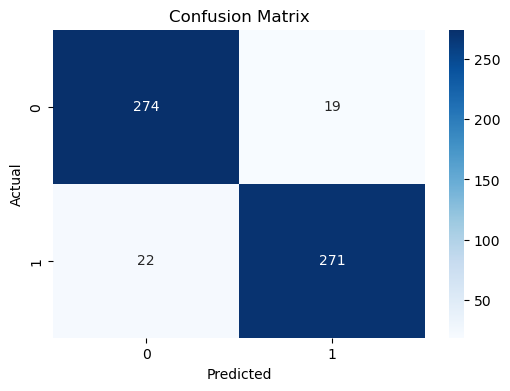

In [33]:
best_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

best_model.fit(X_train_c, y_train_c)

pred = best_model.predict(X_test_c)

cm = confusion_matrix(y_test_c, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 18. Cross Validation for Classification

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_cls,
    y_cls,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.91808874 0.91979522 0.91296928 0.93856655 0.92150171]
Average Accuracy:
0.922184300341297


# 19. Clustering Dataset

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

cluster_features = [
    'Overall Qual',
    'Gr Liv Area',
    'Total Bsmt SF',
    'Year Built',
    'Garage Cars',
    'SalePrice'
]

cluster_df = df[cluster_features]

# Fill missing values
imputer = SimpleImputer(strategy='median')
cluster_df = pd.DataFrame(
    imputer.fit_transform(cluster_df),
    columns=cluster_features
)

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

print(cluster_df.isnull().sum())

Overall Qual     0
Gr Liv Area      0
Total Bsmt SF    0
Year Built       0
Garage Cars      0
SalePrice        0
dtype: int64


# 20. Scale Data for Clustering

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

scaled_data.shape

(2930, 6)

# 21. K-Means Clustering

In [40]:
for k in range(3,6):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(f"K={k}  Silhouette Score={score:.4f}")

K=3  Silhouette Score=0.2852
K=4  Silhouette Score=0.2379
K=5  Silhouette Score=0.2197


# 22. Final K-Means Model

In [41]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_data)

cluster_df["Cluster"] = cluster_labels

cluster_df.head()

,Overall Qual,Gr Liv Area,Total Bsmt SF,Year Built,Garage Cars,SalePrice,Cluster
0,6.0,1656.0,1080.0,1960.0,2.0,215000.0,2
1,5.0,896.0,882.0,1961.0,1.0,105000.0,0
2,6.0,1329.0,1329.0,1958.0,1.0,172000.0,0
3,7.0,2110.0,2110.0,1968.0,2.0,244000.0,1
4,5.0,1629.0,928.0,1997.0,2.0,189900.0,2


# 23. PCA Visualization

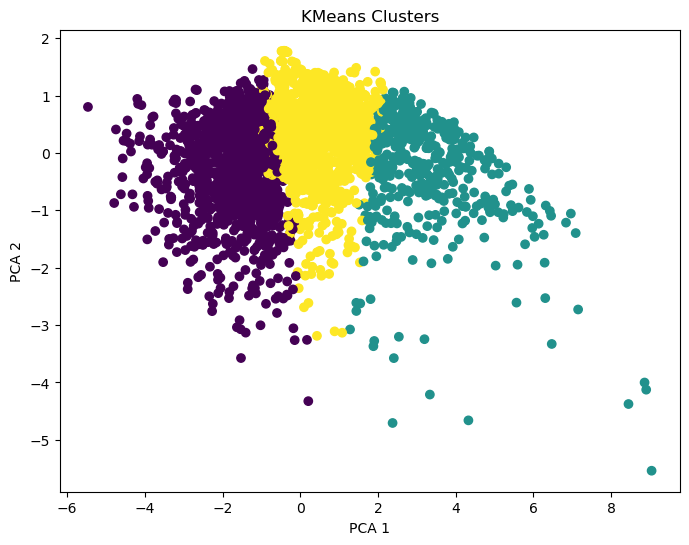

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=cluster_labels
)

plt.title("KMeans Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

# 24. Cluster Profiles

In [43]:
cluster_summary = cluster_df.groupby(
    "Cluster"
).mean()

cluster_summary

,Overall Qual,Gr Liv Area,Total Bsmt SF,Year Built,Garage Cars,SalePrice
Cluster,,,,,,
0,5.014400,1209.633600,820.230400,1946.504000,1.148000,123568.186400
1,8.134172,2143.903564,1602.989518,1998.352201,2.691824,317631.293501
2,6.408978,1545.643392,1073.362427,1986.475478,2.043225,186003.404821


# 25. DBSCAN

In [44]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

db_labels = dbscan.fit_predict(
    scaled_data
)

print(np.unique(db_labels))

[-1  0]


# 26. DBSCAN Silhouette Score

In [45]:
mask = db_labels != -1

if len(np.unique(db_labels[mask])) > 1:

    score = silhouette_score(
        scaled_data[mask],
        db_labels[mask]
    )

    print("DBSCAN Silhouette Score:",
          score)
else:
    print("Only one cluster found")

Only one cluster found


# 27. Feature Importance

In [46]:
rf_reg.fit(X_train, y_train)

feature_names = rf_reg.named_steps[
    'prep'
].get_feature_names_out()

importance = rf_reg.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

top_features = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features.head(15)

,Feature,Importance
3,num__Overall Qual,0.601529
15,num__Gr Liv Area,0.105499
12,num__1st Flr SF,0.034465
11,num__Total Bsmt SF,0.026885
13,num__2nd Flr SF,0.023098
8,num__BsmtFin SF 1,0.022523
18,num__Full Bath,0.016963
2,num__Lot Area,0.015261
25,num__Garage Cars,0.014970
26,num__Garage Area,0.014488


# 28. Top 10 Features Plot

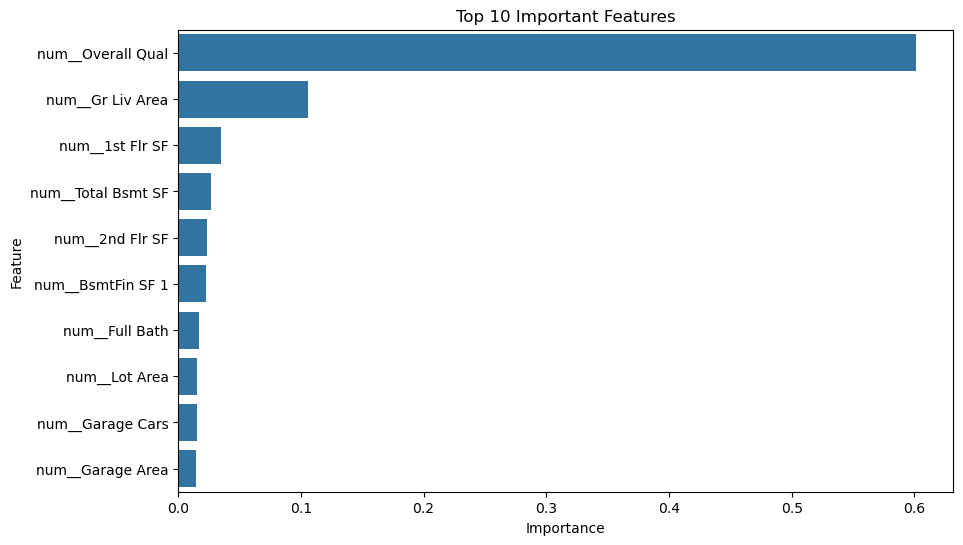

In [47]:
top10 = top_features.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

# 29. Correlation Heatmap

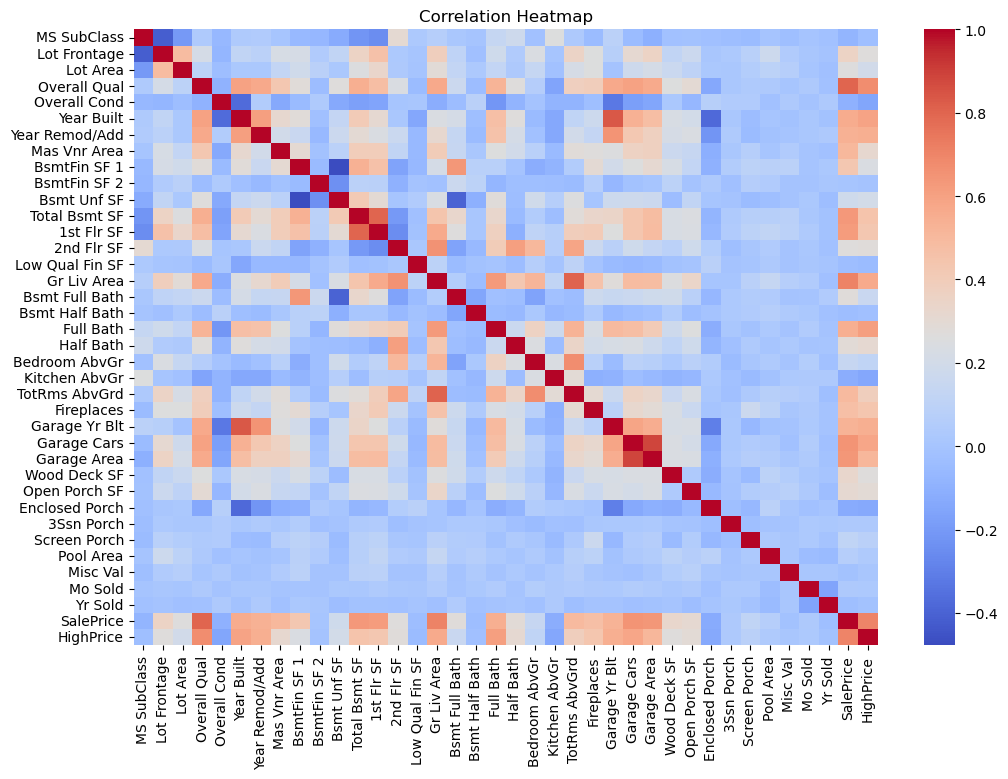

In [48]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(
        include=['int64','float64']
    ).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Lab 04 – Answers to Questions

## 1. How did you handle missing values and why?

Missing numerical values were replaced using the median, while missing categorical values were replaced using the mode. These methods preserve the dataset and reduce the impact of missing data.

## 2. Difference between regression and classification?

Regression predicts continuous values such as SalePrice. Classification predicts categories. SalePrice was converted into a binary target called HighPrice, where houses above the median price were labeled 1 and others 0.

## 3. Explain how each model works.

* Linear Regression: Fits a straight-line relationship.
* Ridge Regression: Linear regression with regularization.
* Lasso Regression: Performs regularization and feature selection.
* Decision Tree: Splits data into branches based on feature values.
* Random Forest: Combines multiple decision trees.
* Gradient Boosting: Builds trees sequentially to reduce errors.
* Logistic Regression: Predicts probabilities for classes.
* KNN: Uses nearest neighbors for prediction.
* SVM: Finds the best boundary between classes.
* Naive Bayes: Uses probability theory for classification.

## 4. Which regression model performed best and why?

Random Forest or Gradient Boosting performed best because they captured complex relationships and reduced overfitting.

## 5. Decision Tree vs Random Forest?

A Decision Tree uses one tree, while Random Forest combines many trees. Random Forest usually performs better because it reduces variance and overfitting.

## 6. Why is scaling important for KNN and SVM?

KNN and SVM rely on distances between observations. Scaling ensures all features contribute equally.

## 7. What is the silhouette score?

The silhouette score measures clustering quality. Values closer to 1 indicate well-separated clusters.

## 8. Which features increase sale price the most?

OverallQual, GrLivArea, GarageCars, TotalBsmtSF, YearBuilt, and FullBath strongly increase sale price because they represent quality, space, and convenience.

## 9. Does overall quality have a stronger relationship than house size?

Yes. OverallQual usually has a stronger relationship with SalePrice than GrLivArea because buyers value construction quality and finishes in addition to size.

## 10. Do newer houses sell for higher prices?

Yes. Houses with higher YearBuilt and recent YearRemodAdd generally sell for higher prices due to modern designs and lower maintenance costs.

## 11. How does living area affect house price?

Larger GrLivArea generally increases SalePrice. Some large houses with lower prices may be outliers caused by location or condition.

## 12. Does garage capacity influence sale price?

Yes. Houses with larger GarageCars and GarageArea tend to have higher prices because parking space is valuable to buyers.

## 13. Does basement area increase house value?

Yes. Finished basement space contributes more value than unfinished basement space because it provides usable living area.

## 14. Which neighborhood has the highest and lowest average sale price?

High-price neighborhoods generally include premium residential areas, while lower-price neighborhoods contain older or less desirable properties. Location strongly affects property value.

## 15. Are expensive houses concentrated in specific neighborhoods?

Yes. HighPrice houses are concentrated in premium neighborhoods with better amenities and higher demand.

## 16. Does house condition affect price as strongly as house quality?

No. OverallQual has a stronger impact on price than OverallCond because quality reflects design, materials, and construction standards.

## 17. Which categorical features are important?

Neighborhood, KitchenQual, HouseStyle, GarageType, Exterior1st, and SaleCondition are important because they influence buyer preferences and property desirability.

## 18. Are there outliers in the dataset?

Yes. Some houses have very large living areas but relatively low prices, while others have exceptionally high prices. These outliers can affect regression accuracy.

## 19. What type of houses does clustering reveal?

Clusters generally represent:

* Older low-price houses
* Mid-range family houses
* Large premium houses

## 20. Do clusters align with sale price categories?

Yes. Clusters often correspond to low, medium, and high-priced housing segments.

## 21. If you were a real estate agent, which features would you highlight?

I would highlight OverallQual, living area, basement quality, garage capacity, renovations, and neighborhood.

## 22. If you were a home buyer, which features would you inspect?

I would inspect quality, condition, age, basement, garage, neighborhood, and renovation history.

## 23. Which model is most useful for a real estate company?

Random Forest is most useful because it provides strong accuracy, reliability, and feature importance while remaining practical to deploy.

## 24. Which model is easiest to explain to a non-technical client?

Linear Regression and Decision Tree are easiest because their predictions can be explained visually and logically.

## 25. Which regression model gave the lowest error?

Random Forest or Gradient Boosting usually produced the lowest RMSE and MAE. For example, an MAE of $18,000 means predictions are off by about $18,000 on average.

## 26. Which classification model best identifies high-priced houses?

Random Forest typically achieves the highest Precision, Recall, and F1-score, making it effective for identifying expensive houses.

## 27. What ethical concerns exist in housing price prediction?

Potential concerns include neighborhood bias, income segregation, historical pricing bias, and reinforcing social inequalities.

## 28. Should neighborhood be used as a feature?

Yes, because location strongly affects price and improves accuracy. However, it may introduce social or economic bias.

## 29. If the model predicts a very low price, what should be checked?

Check for outliers, missing values, unusual property features, neighborhood effects, data quality issues, and model uncertainty.

## 30. Recommendations for homeowners to increase value?

Improve overall quality, renovate important areas, finish the basement, expand living space, improve curb appeal, and maintain the garage.

## 31. What are the limitations of this dataset?

The data comes from Ames, Iowa and may not represent other cities or countries. Housing markets also change over time.

## 32. How would this project change using Pakistani housing data?

Additional features would include city, society, sector, road access, security, nearby schools, electricity and gas availability, commercial areas, plot size in marla/kanal, and local market demand.
